In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import os

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
dataset = torchvision.datasets.CIFAR10(root="./data", download=True,
                     transform=transforms.Compose([
                     transforms.ToTensor()
                     ]))

Files already downloaded and verified


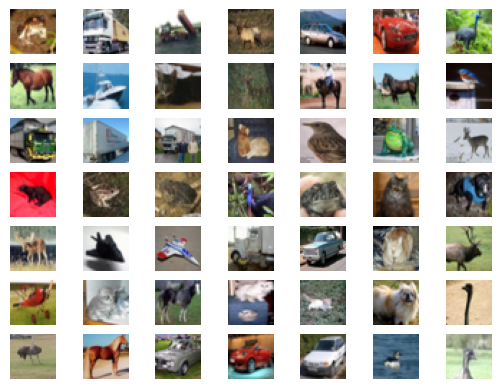

In [4]:
for i in range(49):
    plt.subplot(7, 7, i+1)
    plt.axis('off')
    plt.imshow(dataset[i][0].permute(1,2,0))
plt.show()

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding='same')
        self.lrelu = nn.LeakyReLU(0.2)
        self.conv2 = nn.Conv2d(64, 128, 3, 2, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, 2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, 2, padding=1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)
        self.ll1 = nn.LazyLinear(1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        out = self.lrelu(self.conv1(x))
        out = self.lrelu(self.conv2(out))
        out = self.lrelu(self.conv3(out))
        out = self.lrelu(self.conv4(out))
        out = self.dropout(self.flatten(out))
        out = self.ll1(out)
        return self.sigmoid(out)

In [6]:
discriminator = Discriminator().to(device)
summary(discriminator, (3, 32, 32))

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         LeakyReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         LeakyReLU-4          [-1, 128, 16, 16]               0
            Conv2d-5            [-1, 128, 8, 8]         147,584
         LeakyReLU-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 4, 4]         295,168
         LeakyReLU-8            [-1, 256, 4, 4]               0
           Flatten-9                 [-1, 4096]               0
          Dropout-10                 [-1, 4096]               0
           Linear-11                    [-1, 1]           4,097
          Sigmoid-12                    [-1, 1]               0
Total params: 522,497
Trainable params: 522,497
Non-trainable params: 0
-------------------------------

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.ll1 = nn.Linear(latent_dim, 256*4*4)
        self.lrelu = nn.LeakyReLU(0.2)
        self.conv1 = nn.ConvTranspose2d(256, 128, 4, 2, padding=1)
        self.conv2 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv3 = nn.ConvTranspose2d(128, 128, 4, 2, padding=1)
        self.conv4 = nn.Conv2d(128, 3, 3, padding='same')
        self.tanh = nn.Tanh()
    
    def forward(self, x):
        out = self.lrelu(self.ll1(x))
        out = out.view(-1, 256, 4, 4)
        out = self.lrelu(self.conv1(out))
        out = self.lrelu(self.conv2(out))
        out = self.lrelu(self.conv3(out))
        out = self.conv4(out)
        return self.tanh(out)

In [8]:
generator = Generator(100).to(device)
summary(generator, (100,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 4096]         413,696
         LeakyReLU-2                 [-1, 4096]               0
   ConvTranspose2d-3            [-1, 128, 8, 8]         524,416
         LeakyReLU-4            [-1, 128, 8, 8]               0
   ConvTranspose2d-5          [-1, 128, 16, 16]         262,272
         LeakyReLU-6          [-1, 128, 16, 16]               0
   ConvTranspose2d-7          [-1, 128, 32, 32]         262,272
         LeakyReLU-8          [-1, 128, 32, 32]               0
            Conv2d-9            [-1, 3, 32, 32]           3,459
             Tanh-10            [-1, 3, 32, 32]               0
Total params: 1,466,115
Trainable params: 1,466,115
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 2.73
Params size (MB): 5.59
Estimat

In [9]:
def generate_latent_points(latent_dim, n_samples):
    x_input = np.random.randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

In [10]:
def generate_fake_samples(g_model, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    x = g_model(torch.Tensor(x_input).to(device))
    y = np.zeros((n_samples, 1))
    return x, y

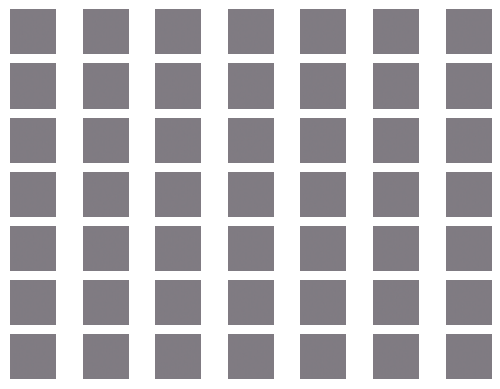

In [11]:
latent_dim = 100
n_samples = 49
x, _ = generate_fake_samples(generator, latent_dim, n_samples)
x = (x+1)/2
for i in range(n_samples):
    plt.subplot(7, 7, 1 + i)
    plt.axis('off')
    plt.imshow(x[i].cpu().detach().permute(1, 2, 0))
plt.show()

In [12]:
NUM_EPOCHS = 100
LR = 2e-4
N_BATCH = 128
LATENT_DIM = 100

In [13]:
dataloader = DataLoader(dataset, batch_size=N_BATCH//2, shuffle=True, drop_last=True)

In [14]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [15]:
netG = Generator(100).to(device)
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(0.5, 0.999))

In [16]:
def save_image(img_list, epoch):
    plt.figure(figsize=(16, 16));
    plt.axis("off")
    plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
    if not os.path.exists('generated'):
        os.makedirs('generated')
    plt.savefig("generated/img%d.png" % epoch, bbox_inches='tight', pad_inches=0)  

Processing Epoch 100: 100%|██████████| 781/781 [00:39<00:00, 19.83it/s]


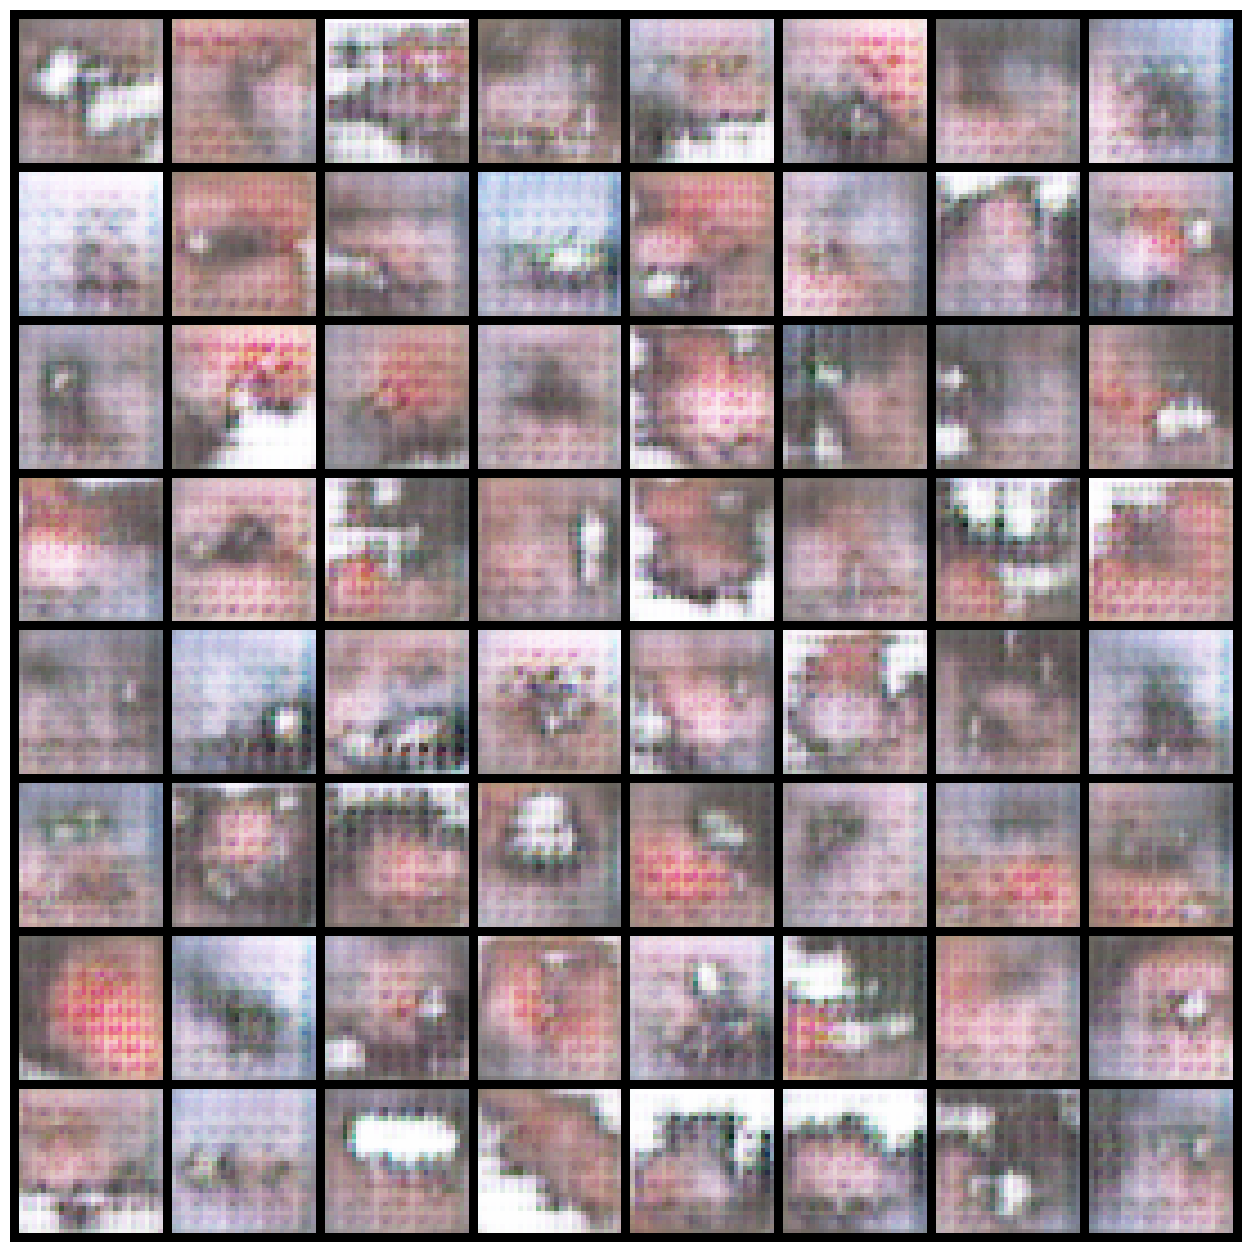

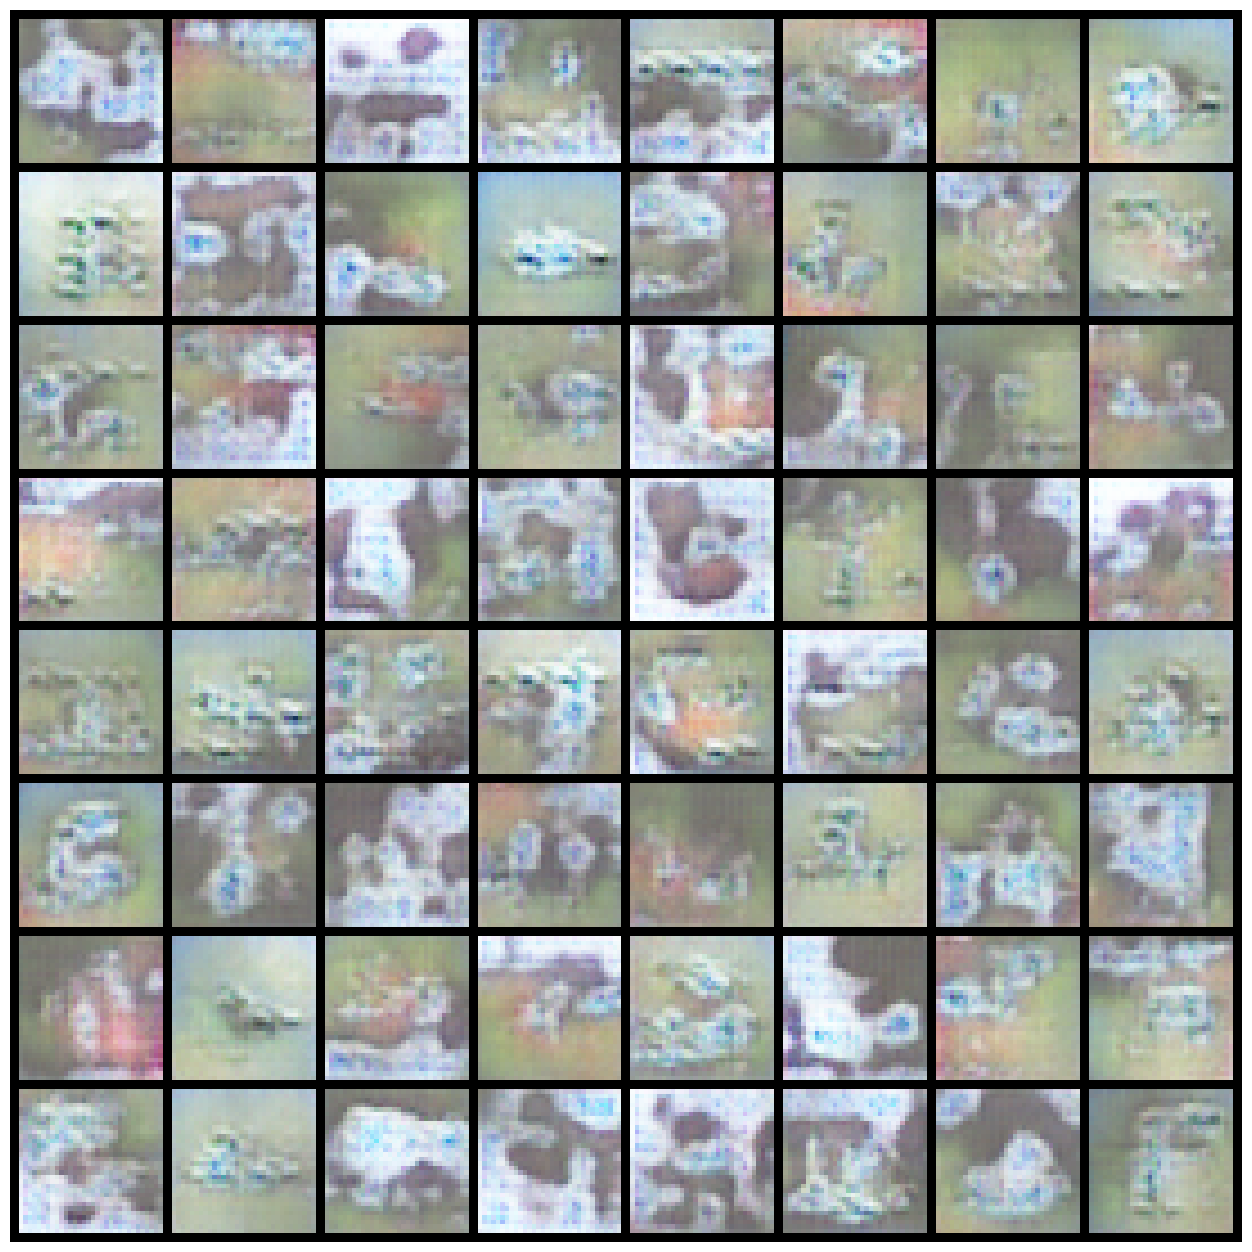

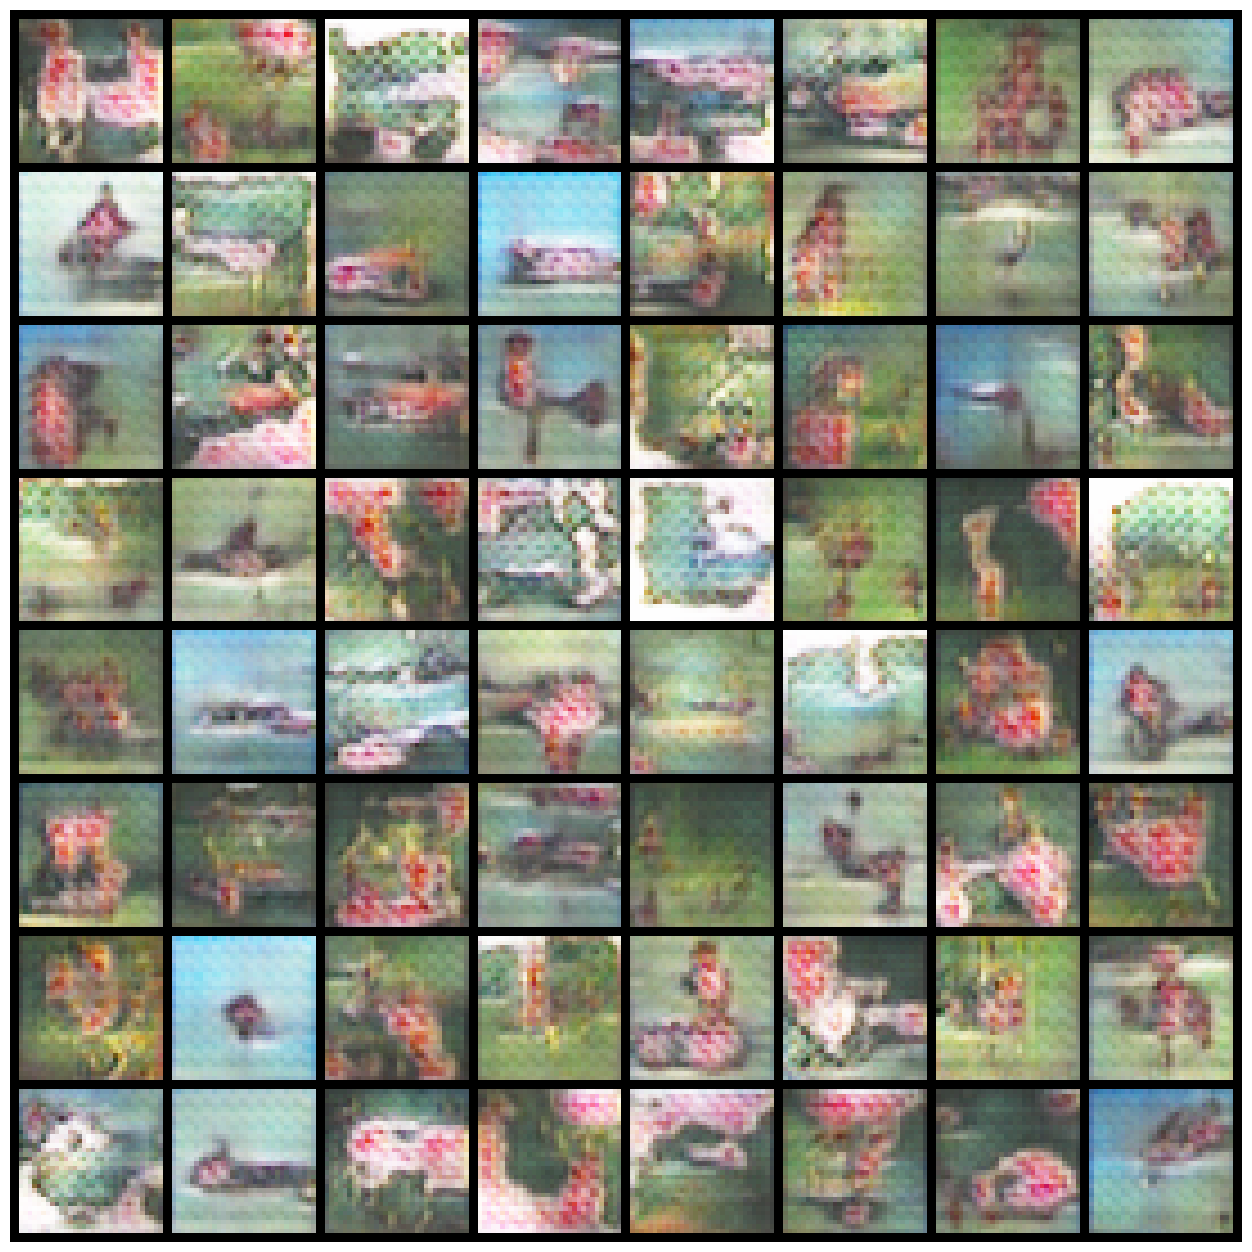

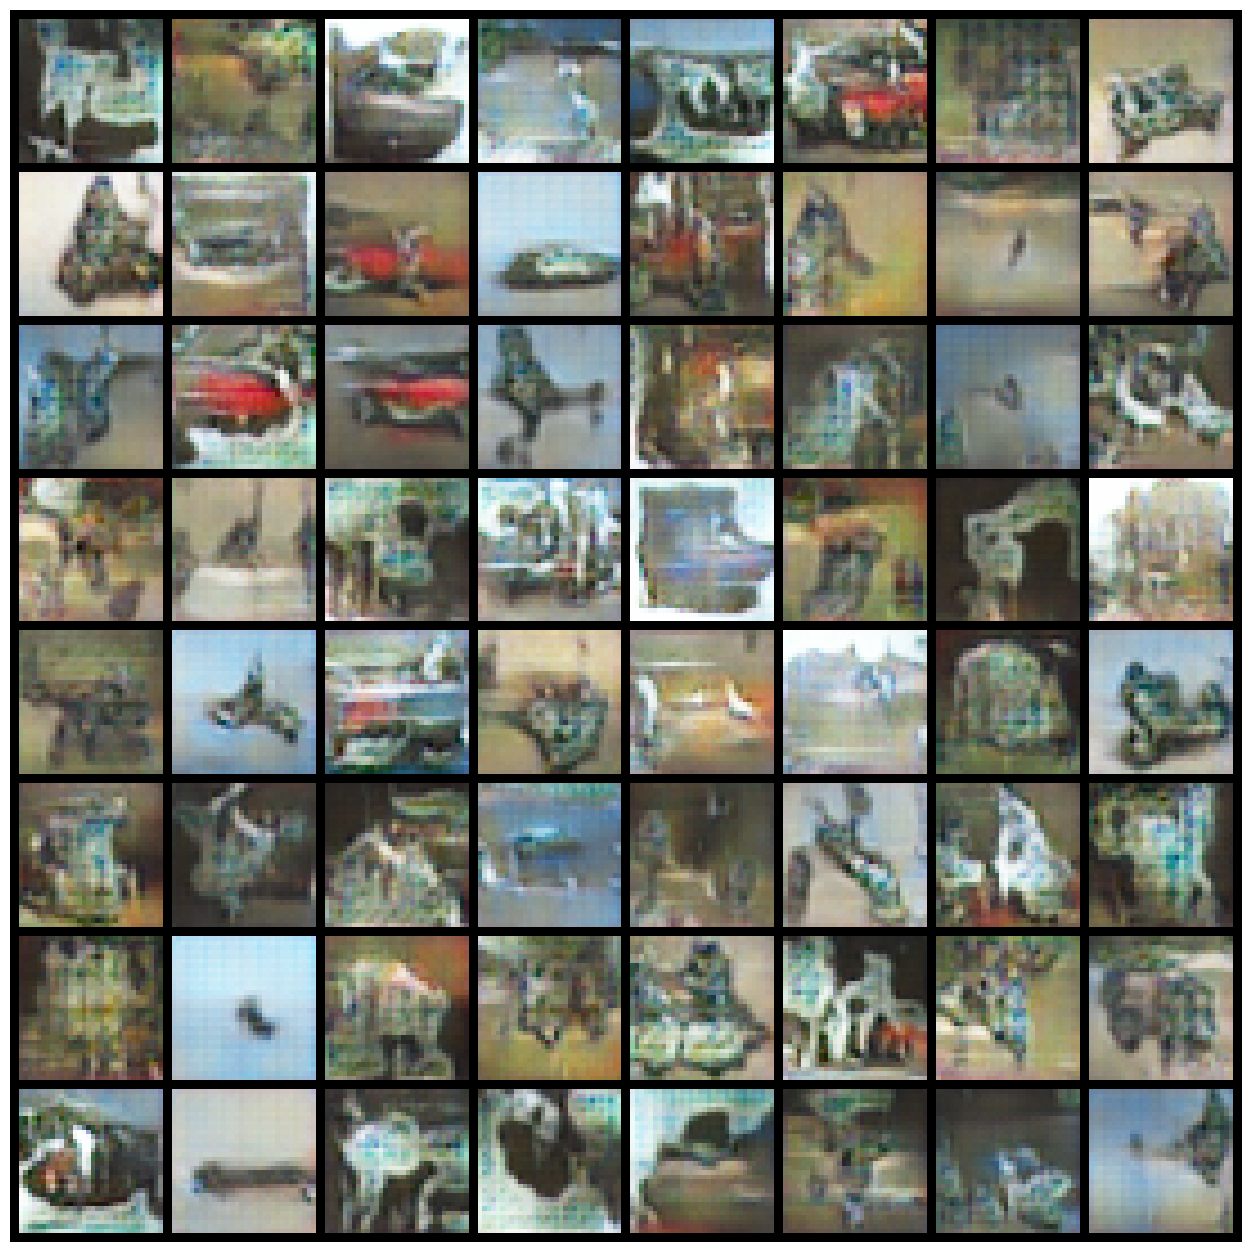

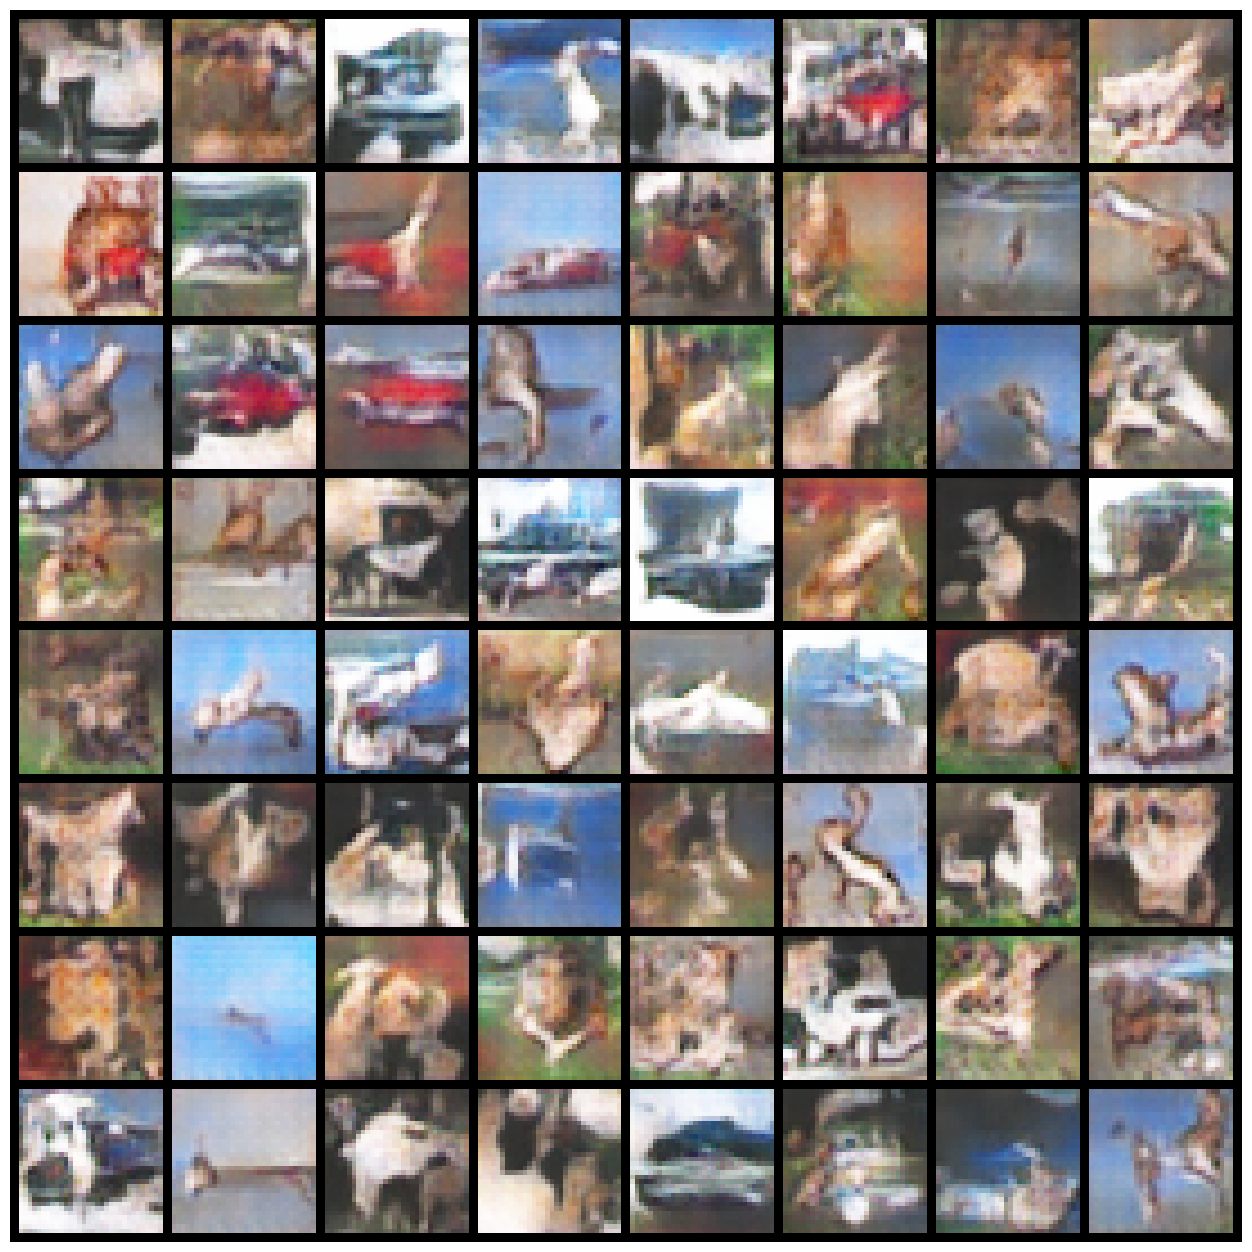

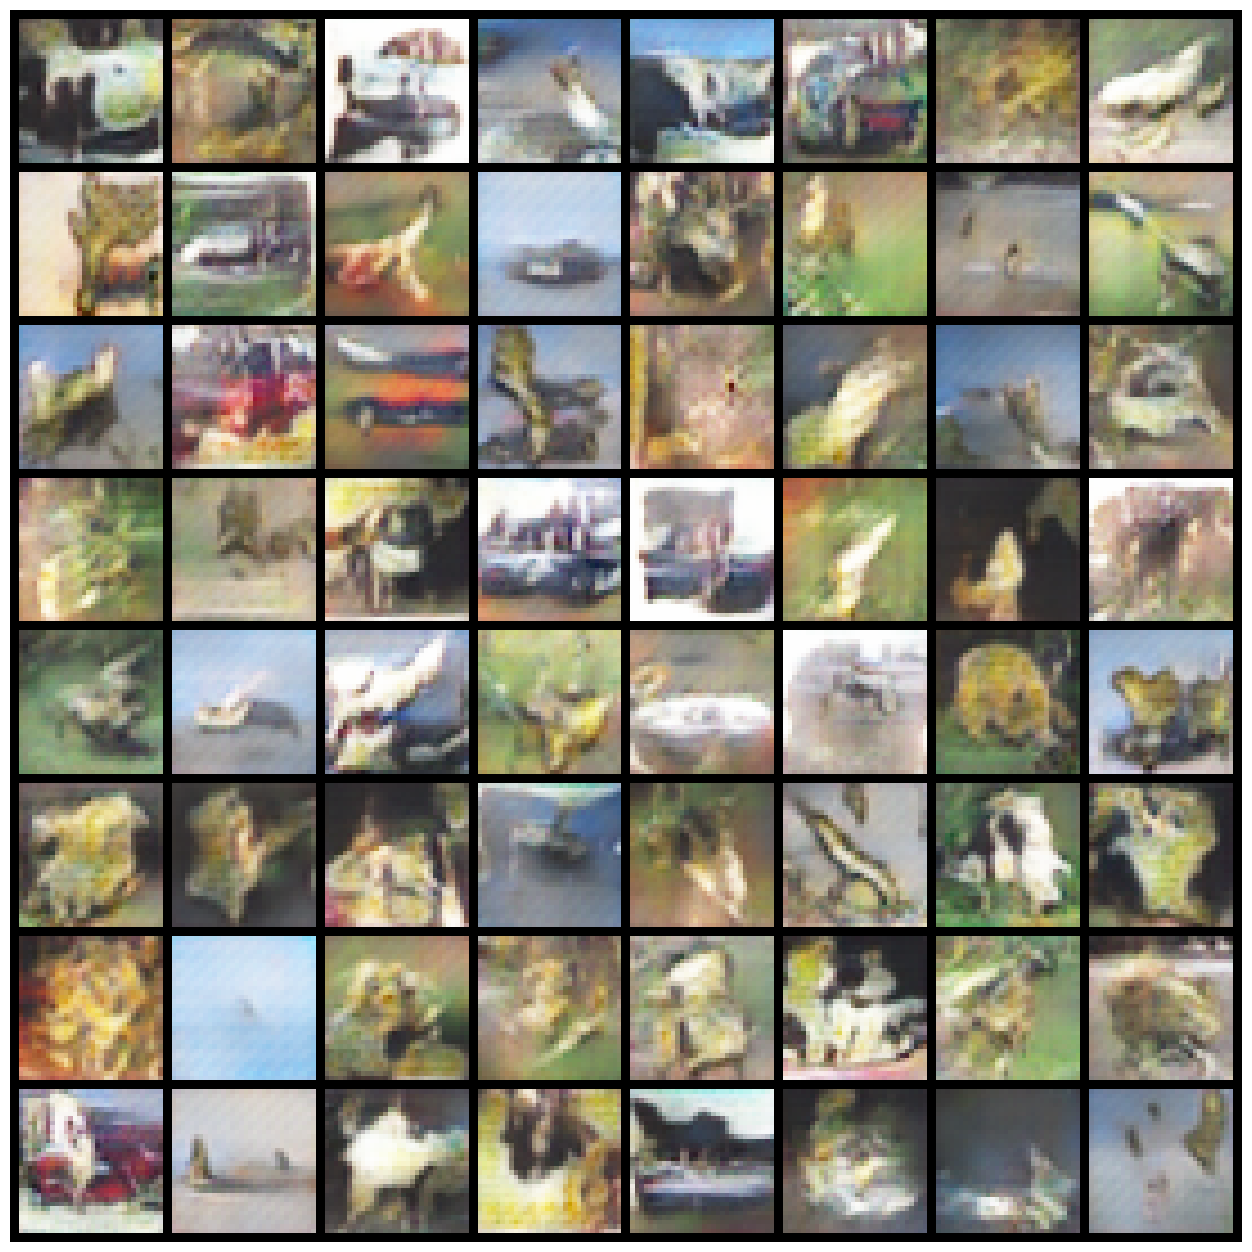

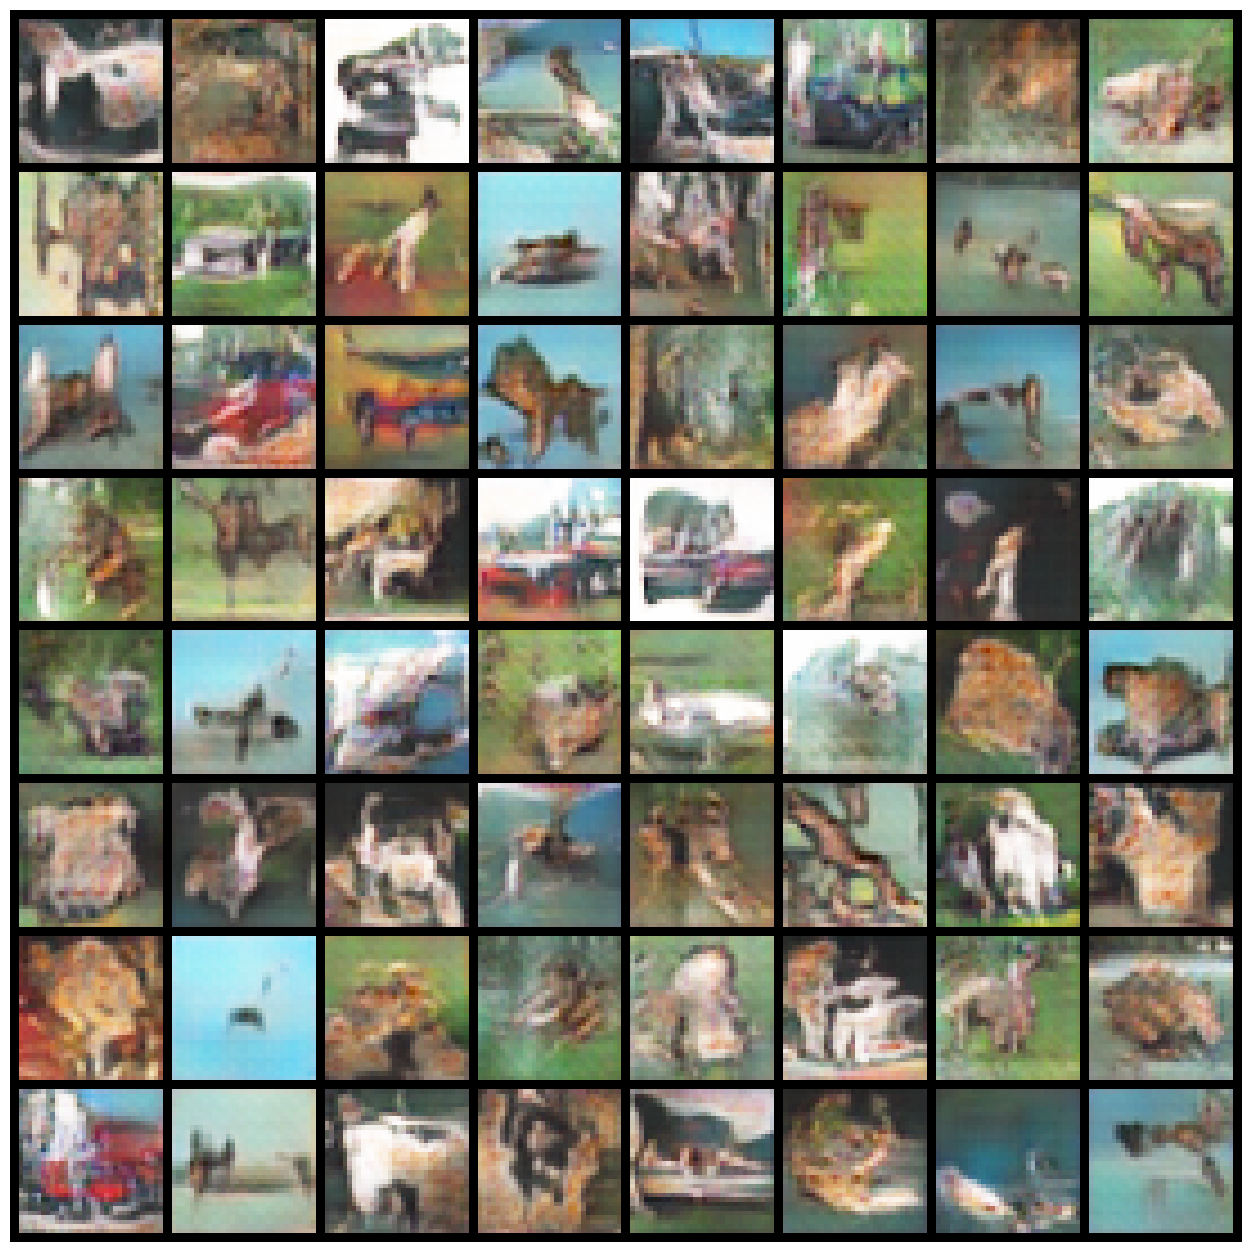

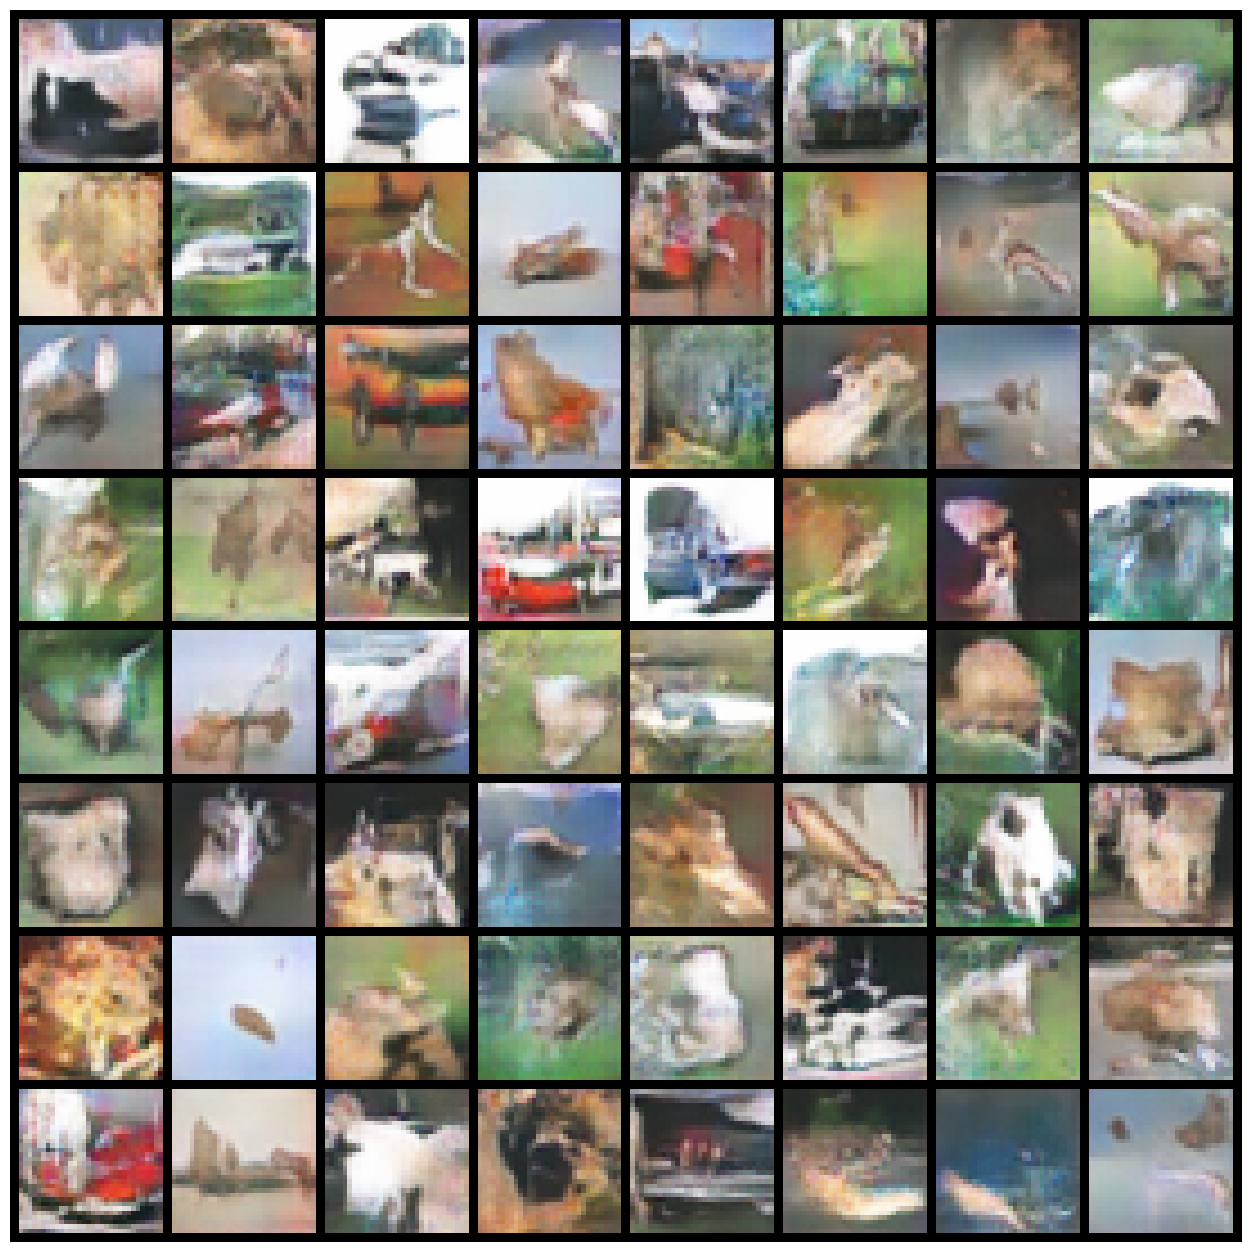

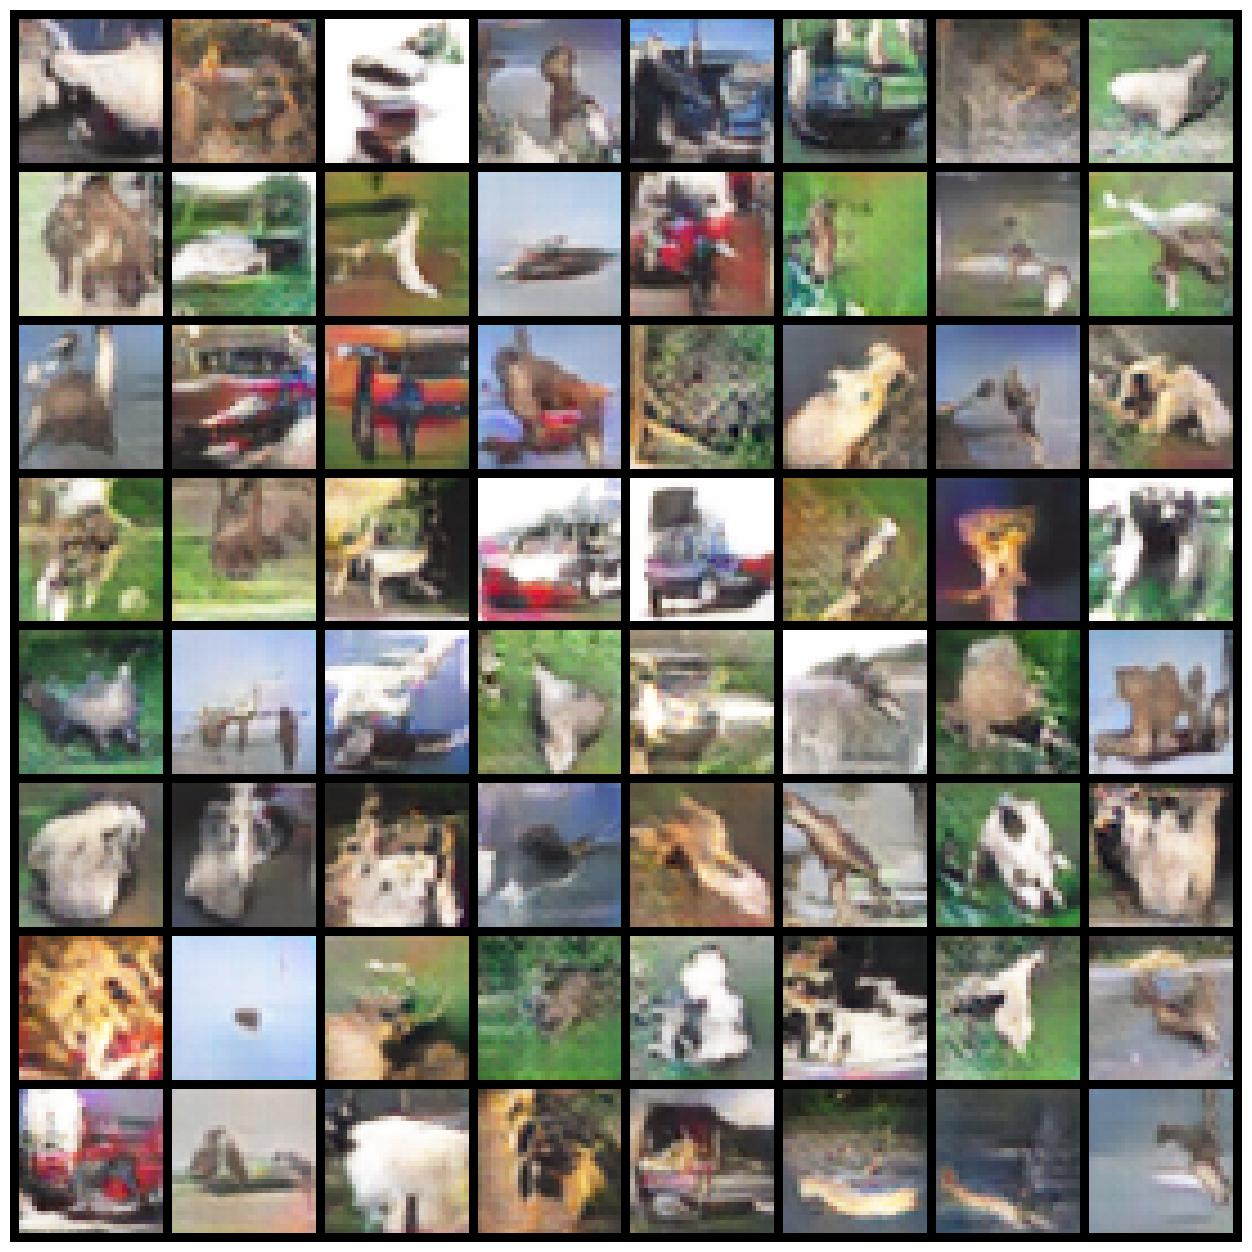

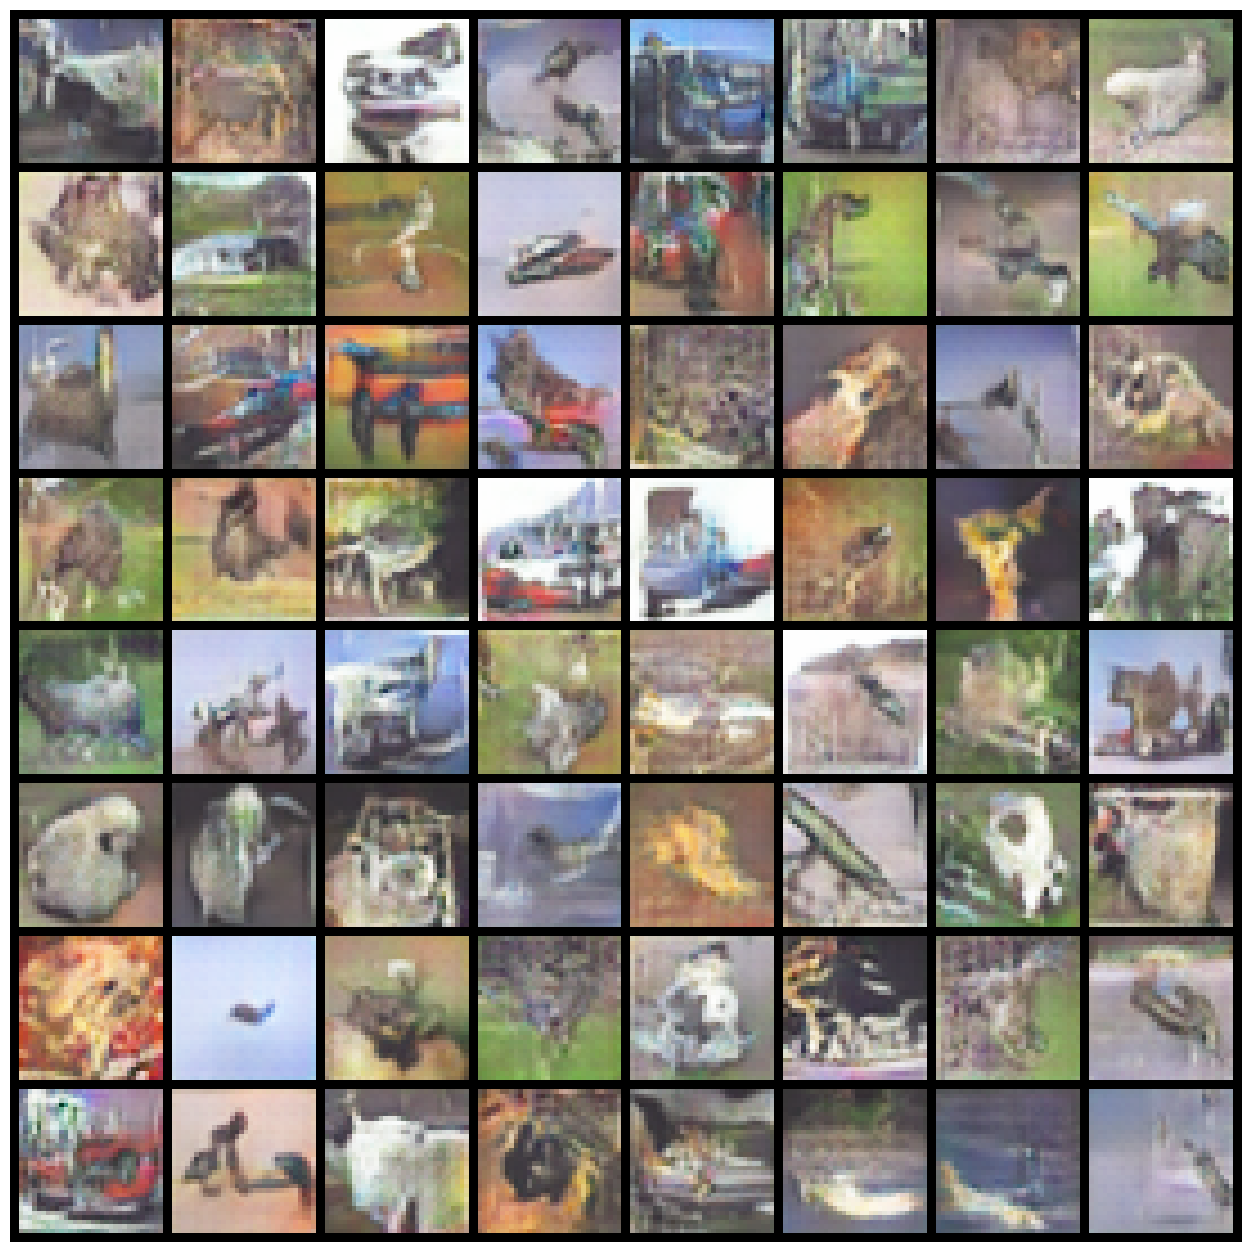

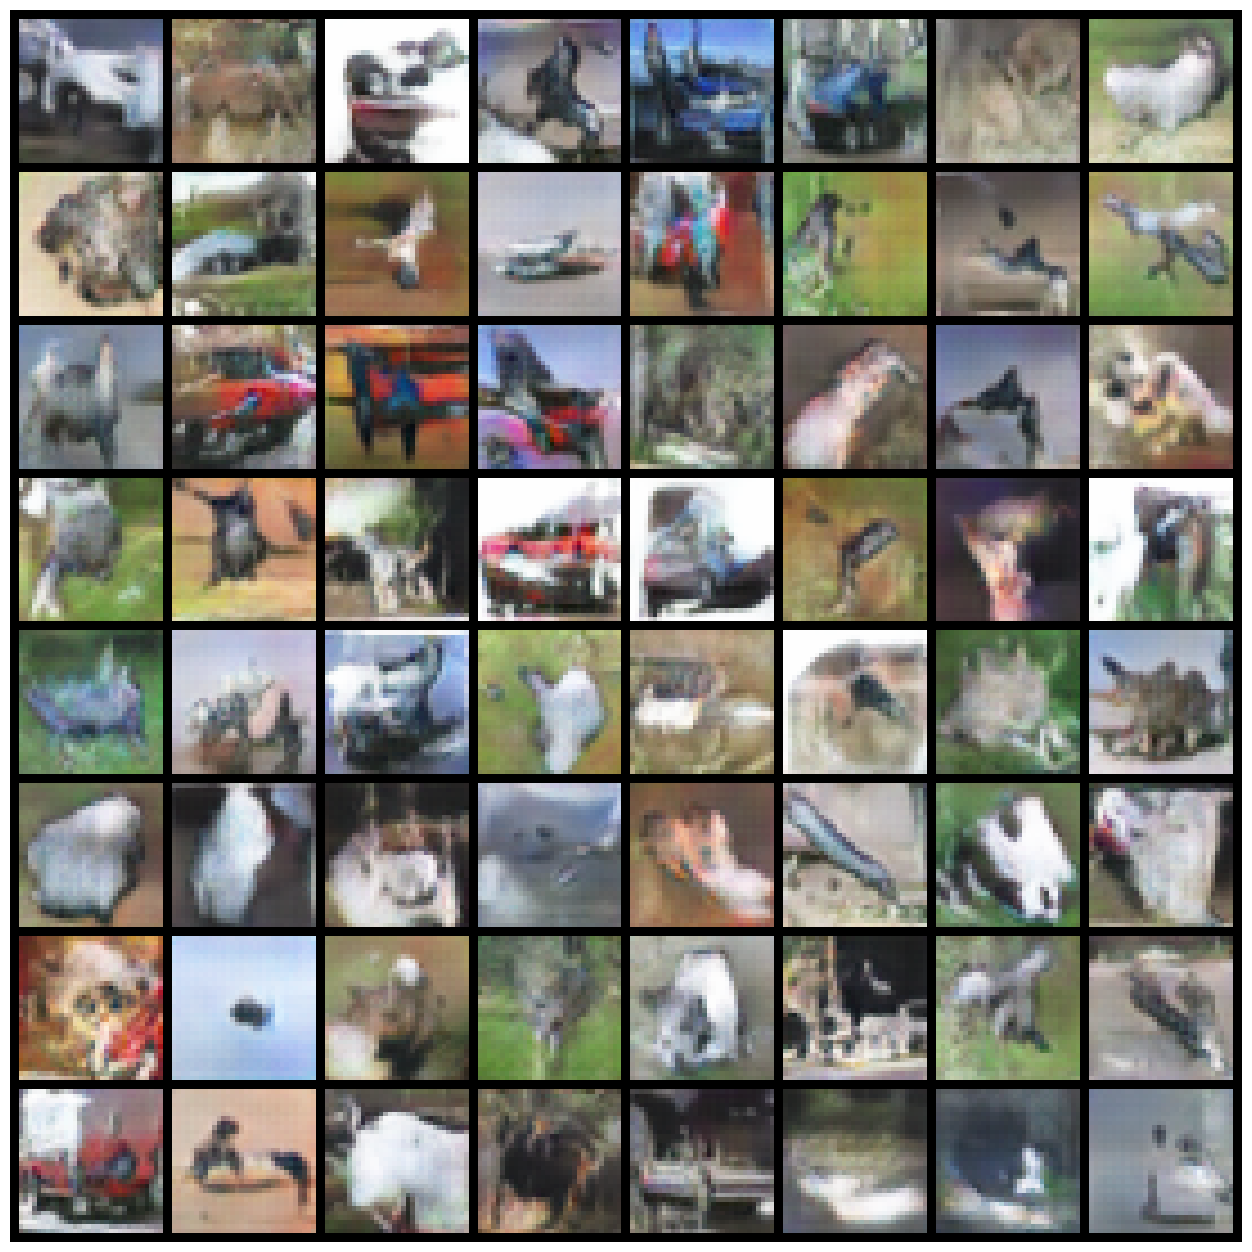

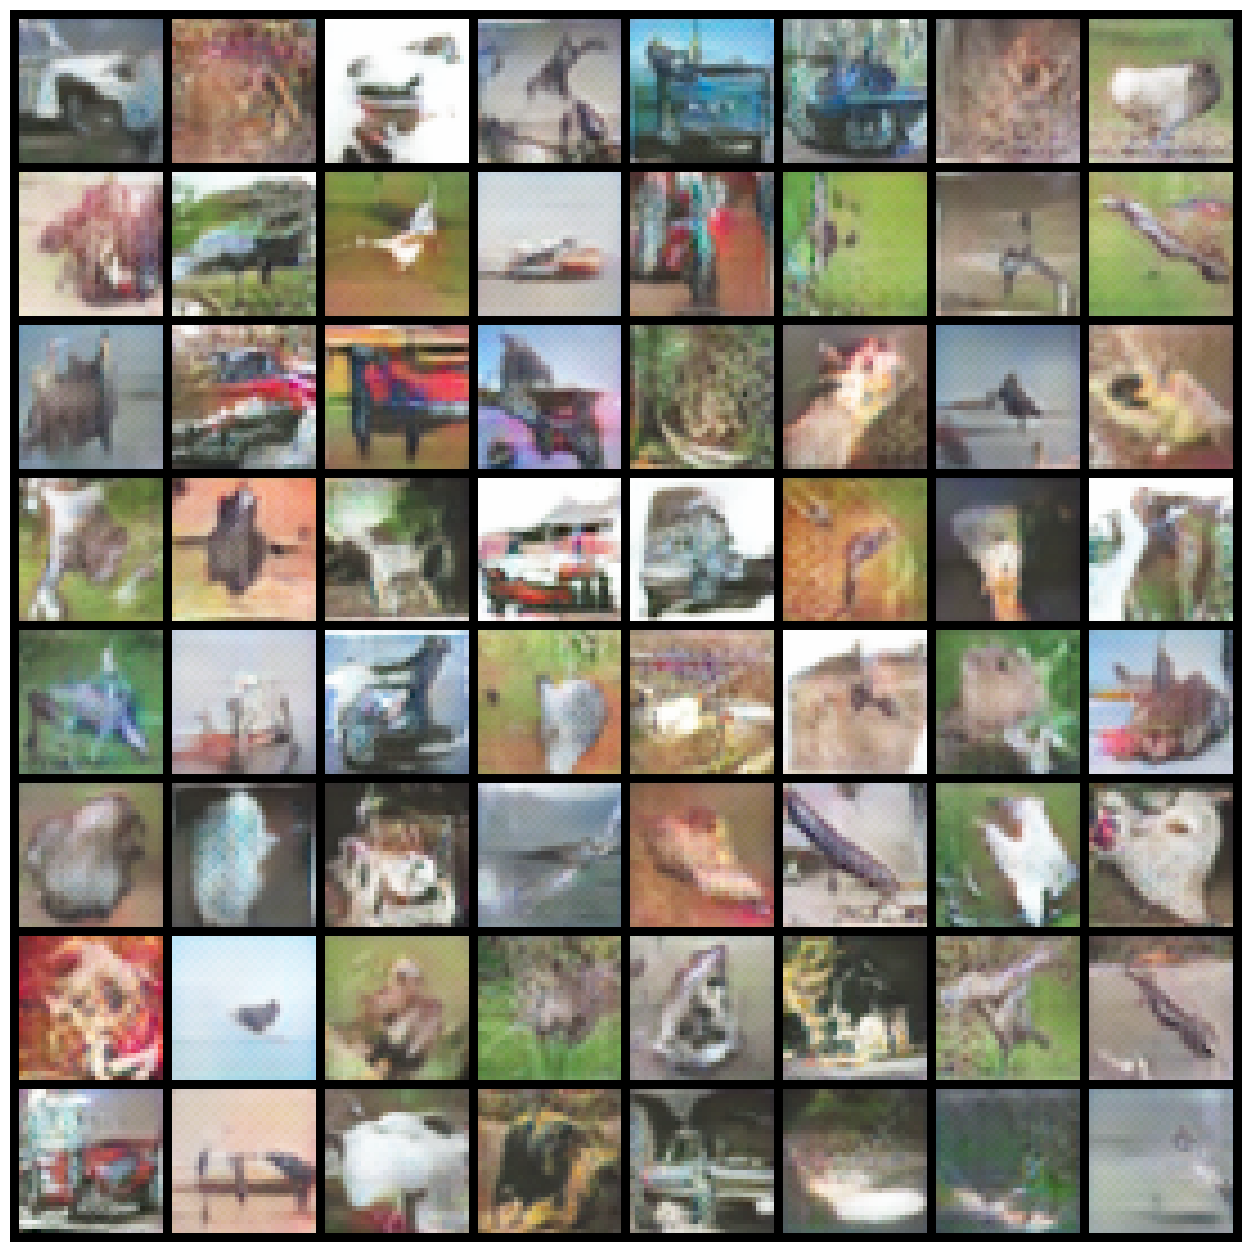

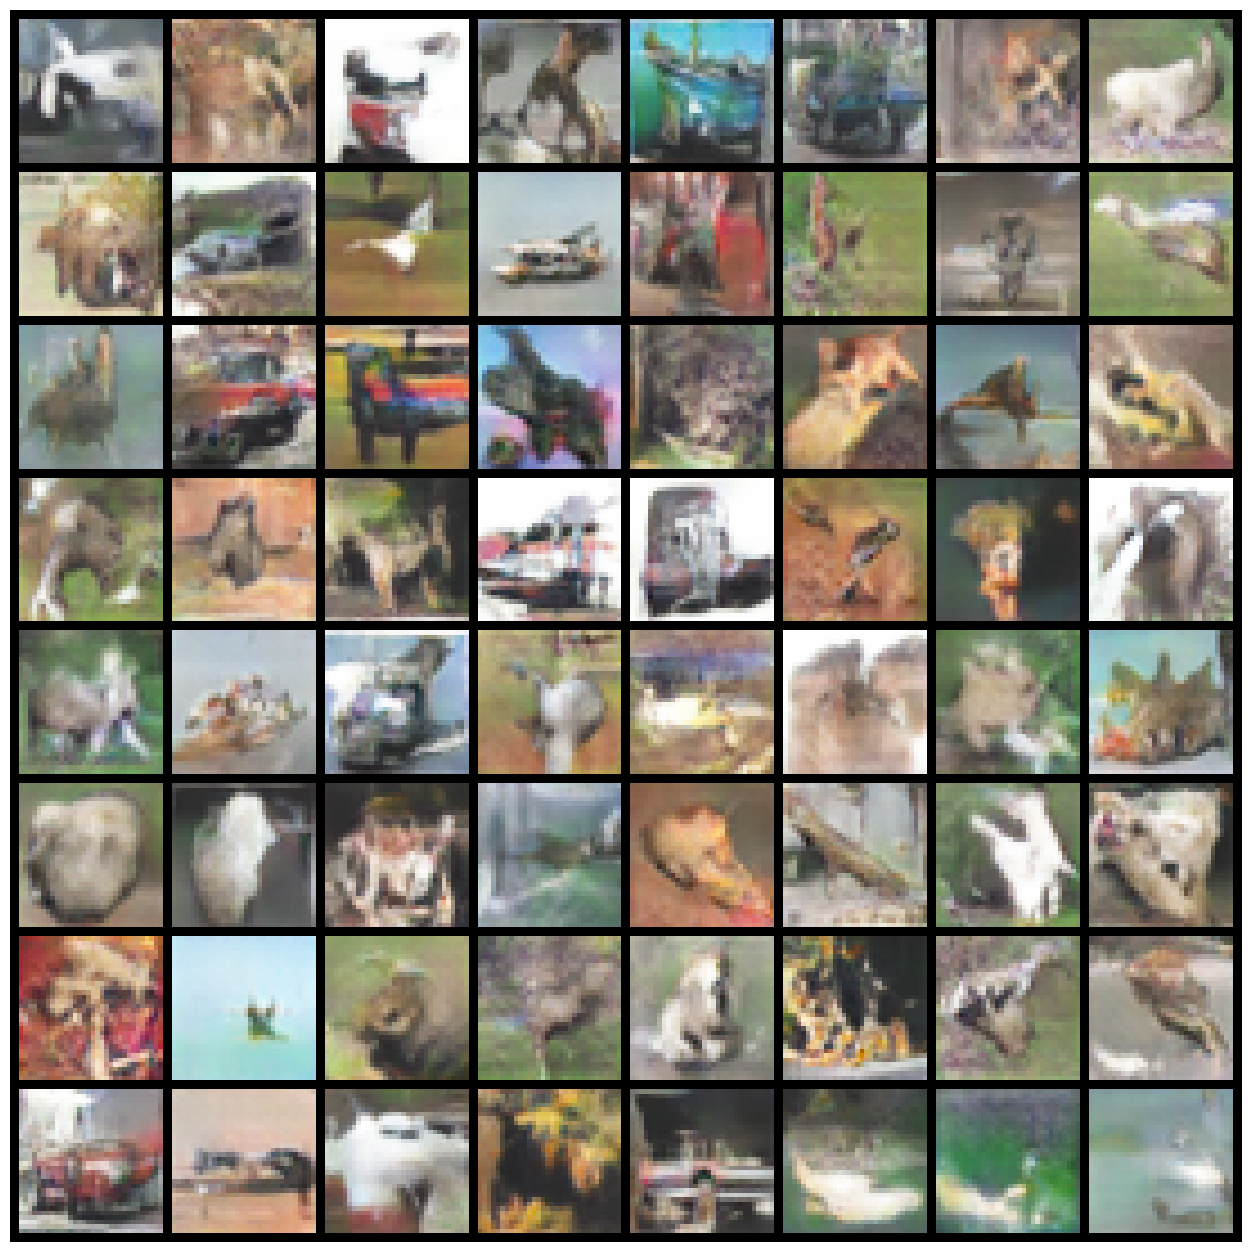

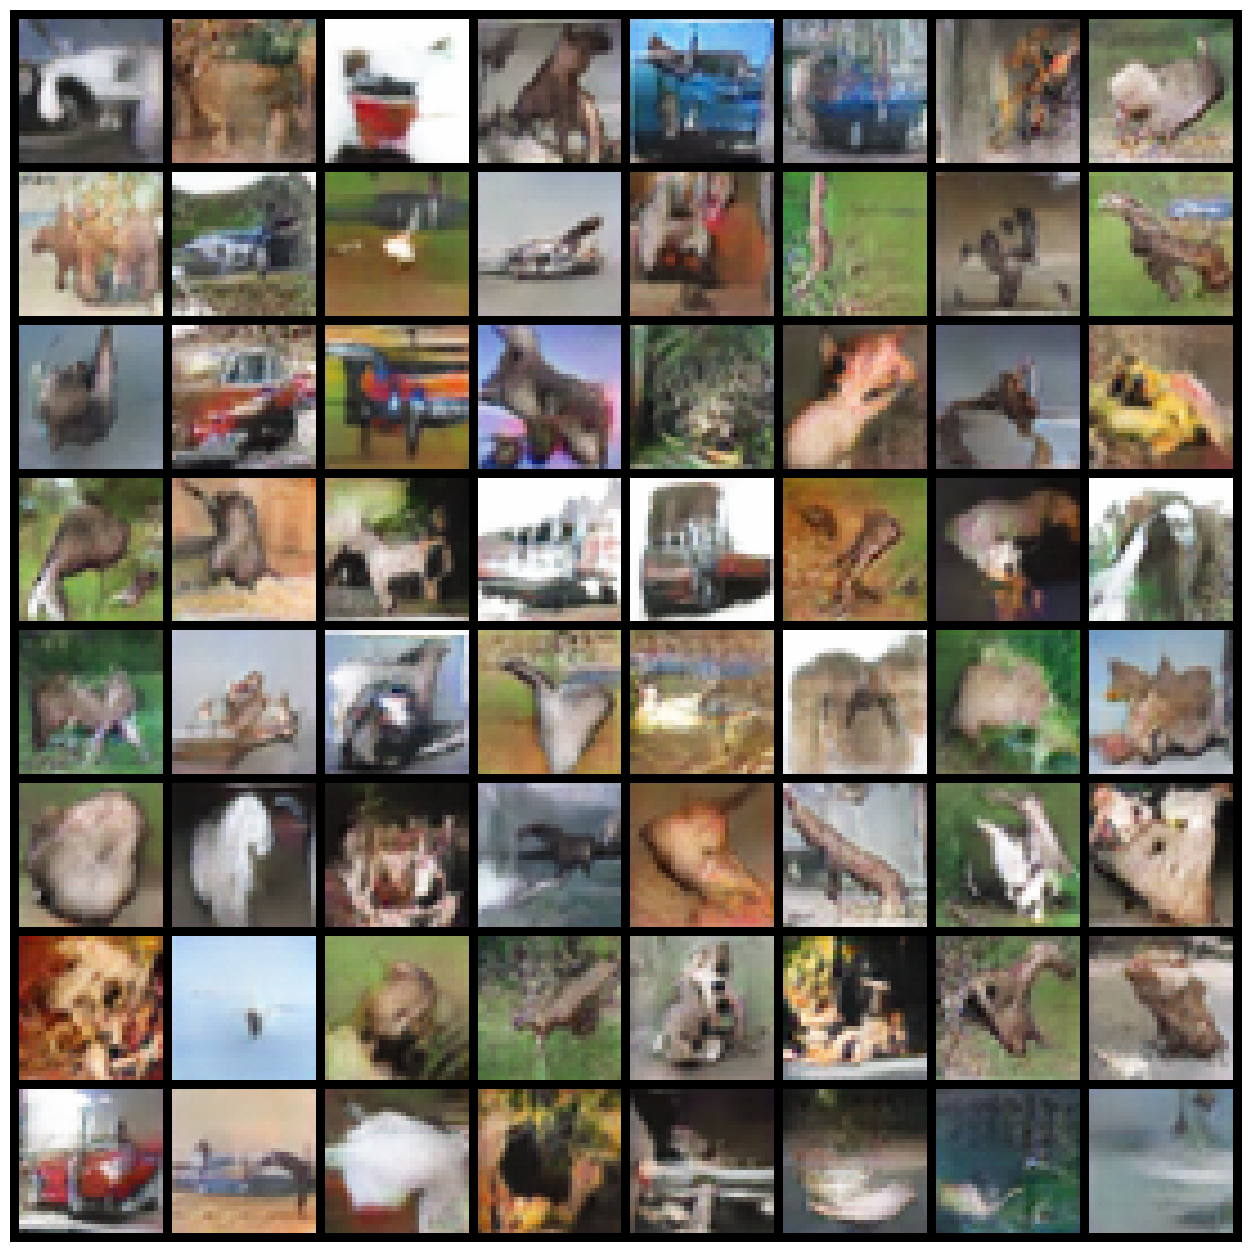

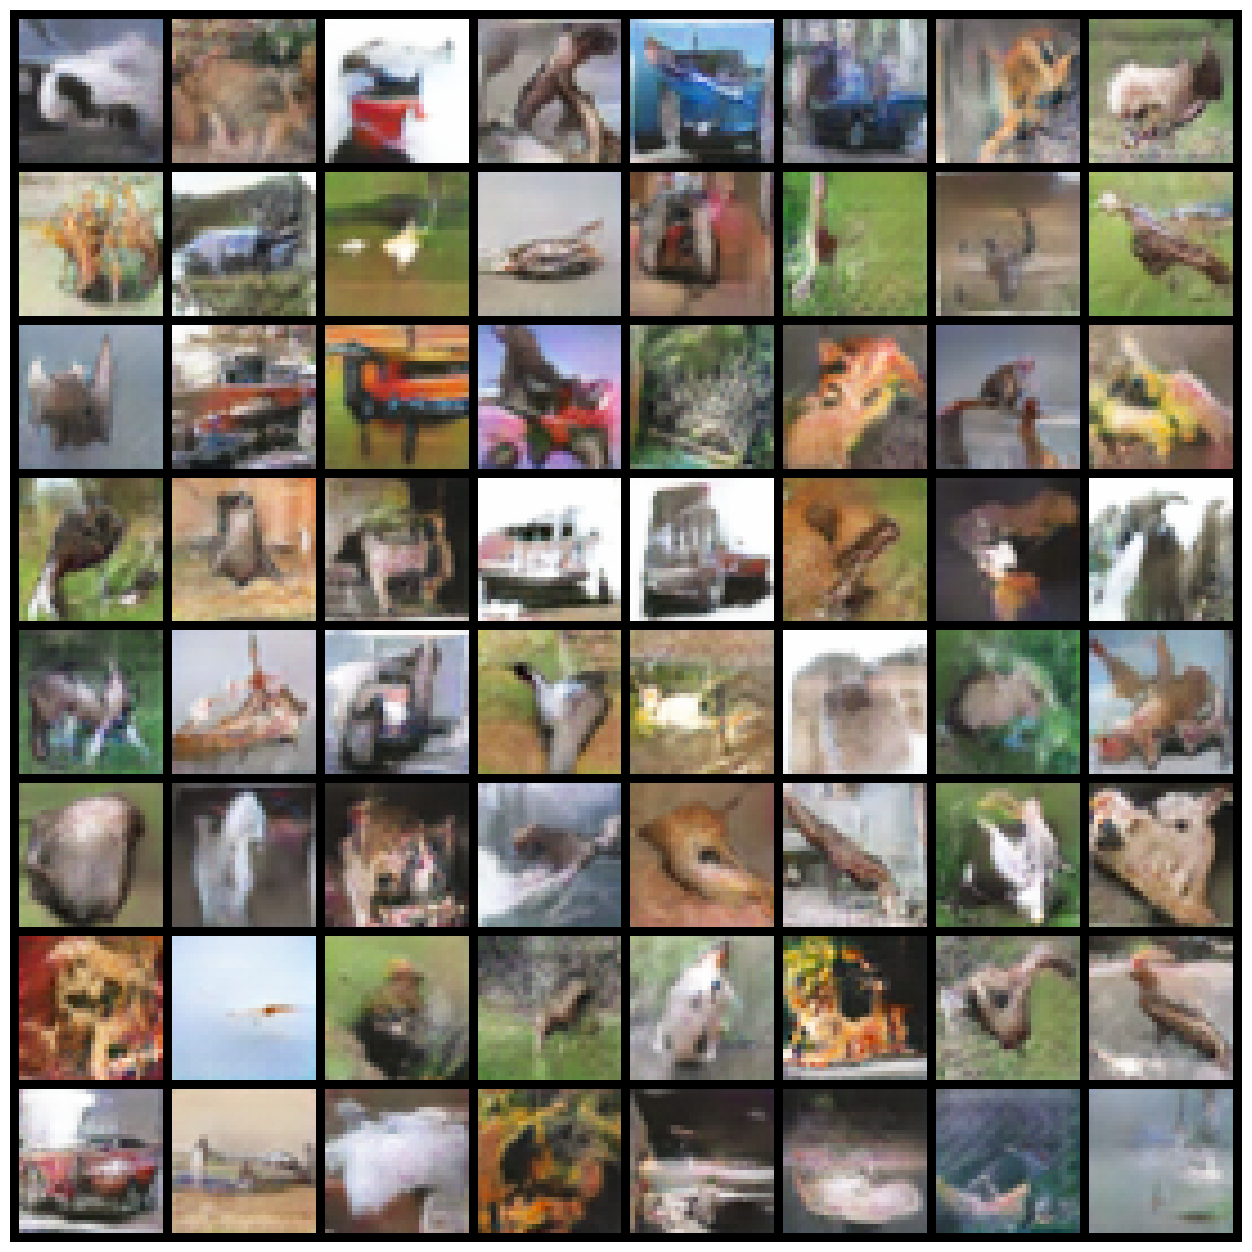

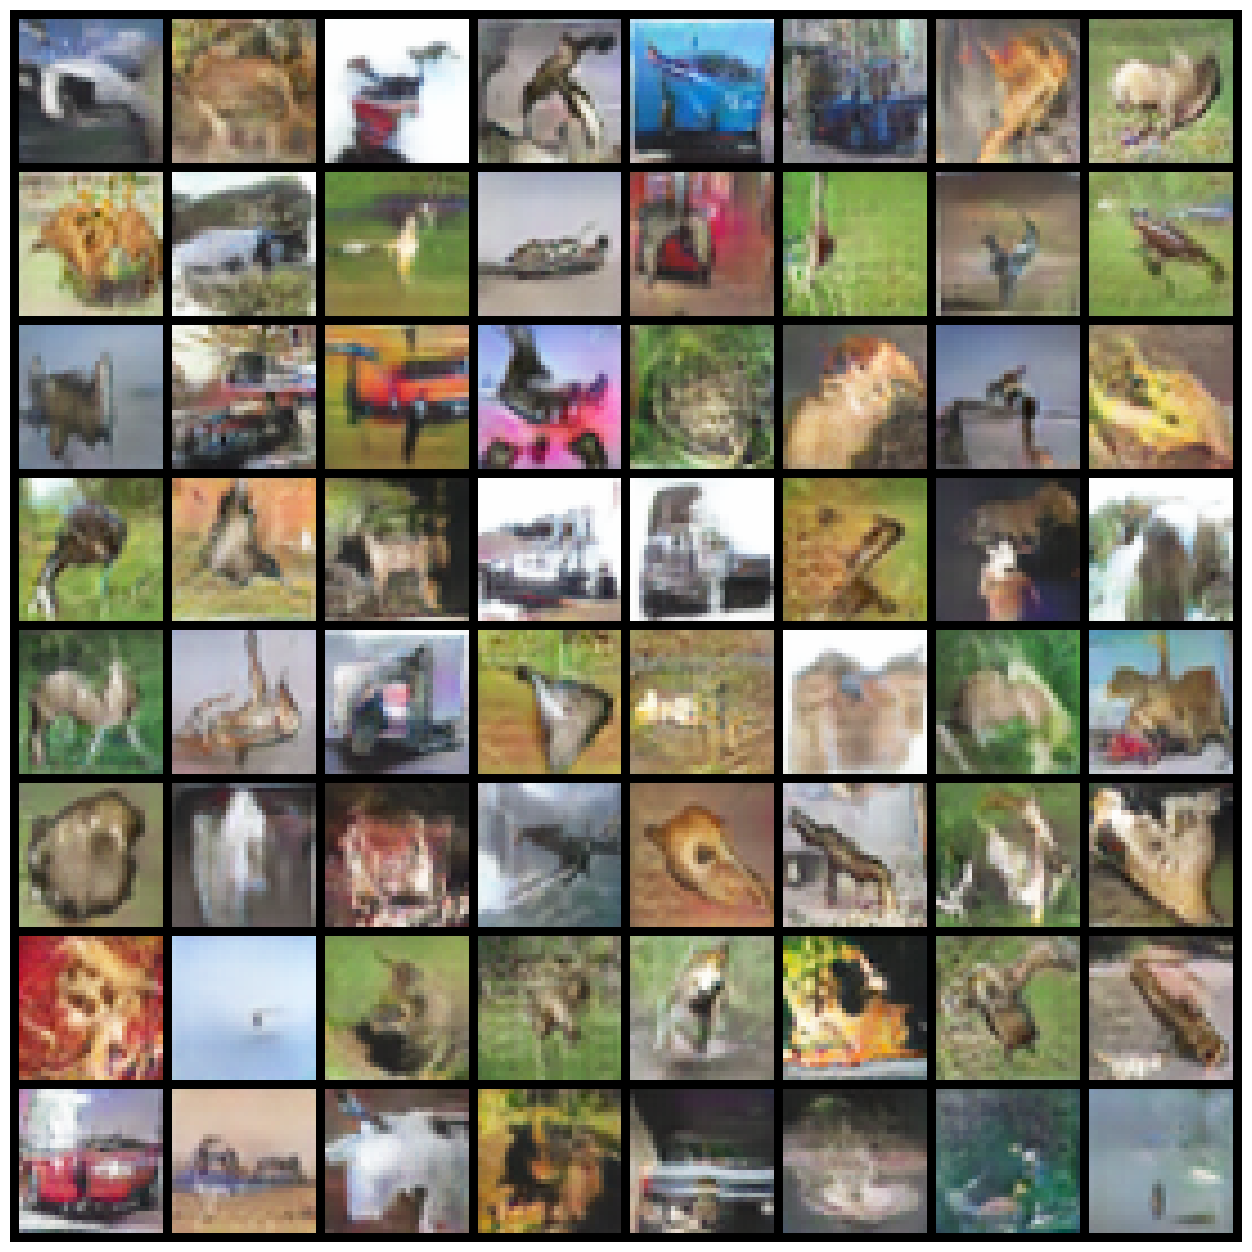

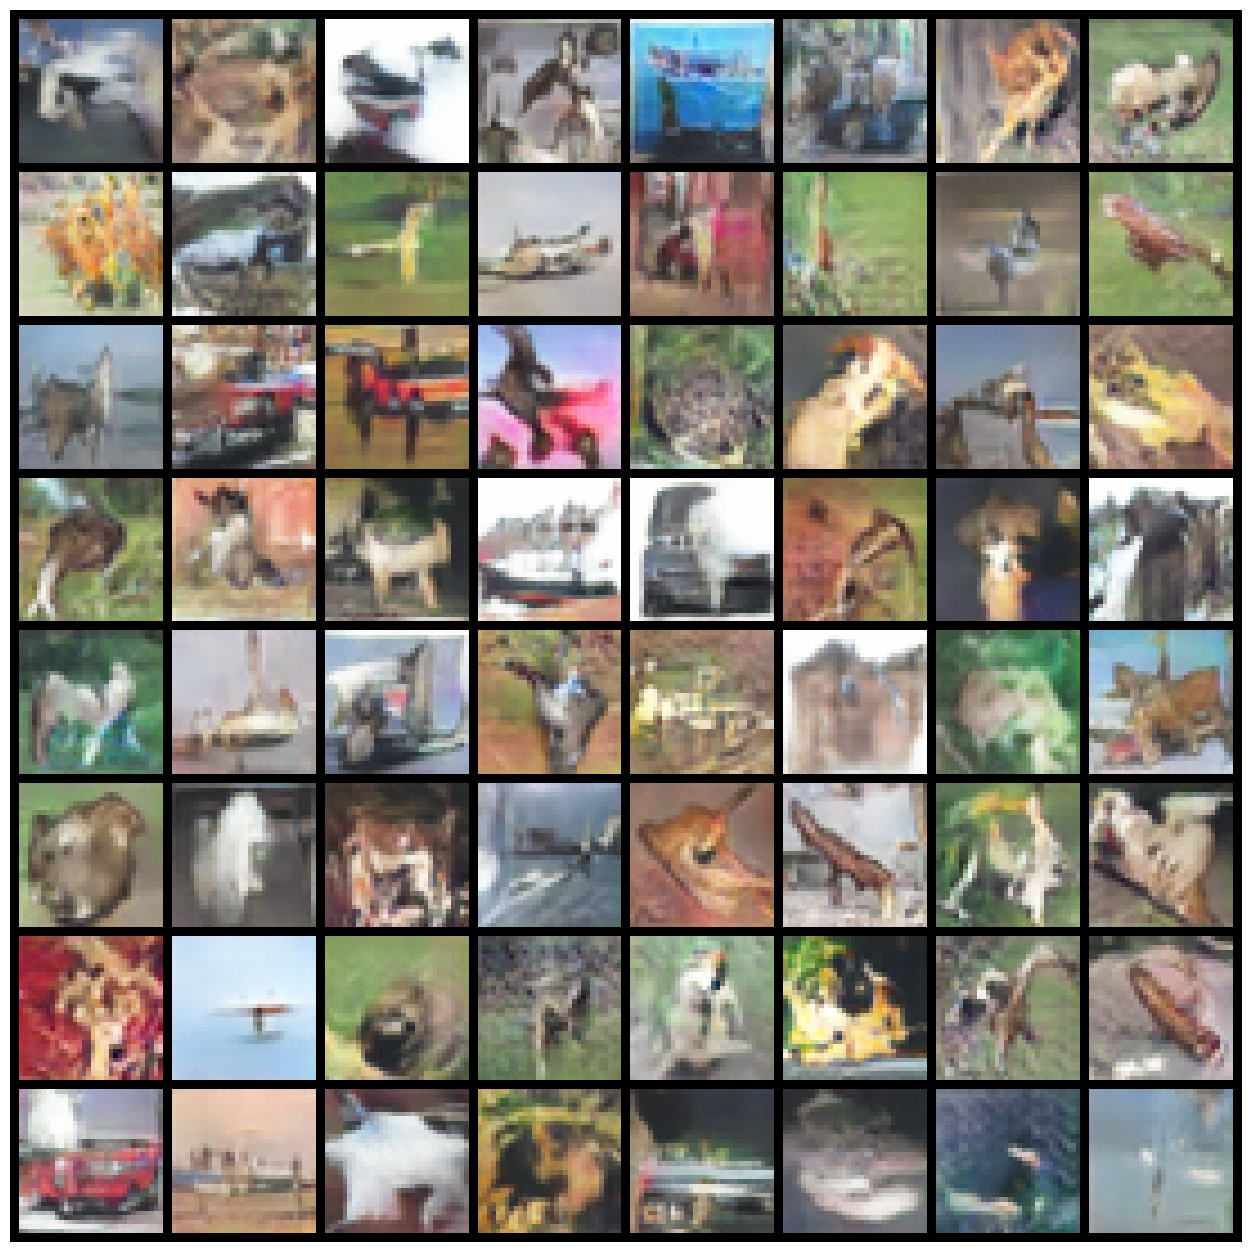

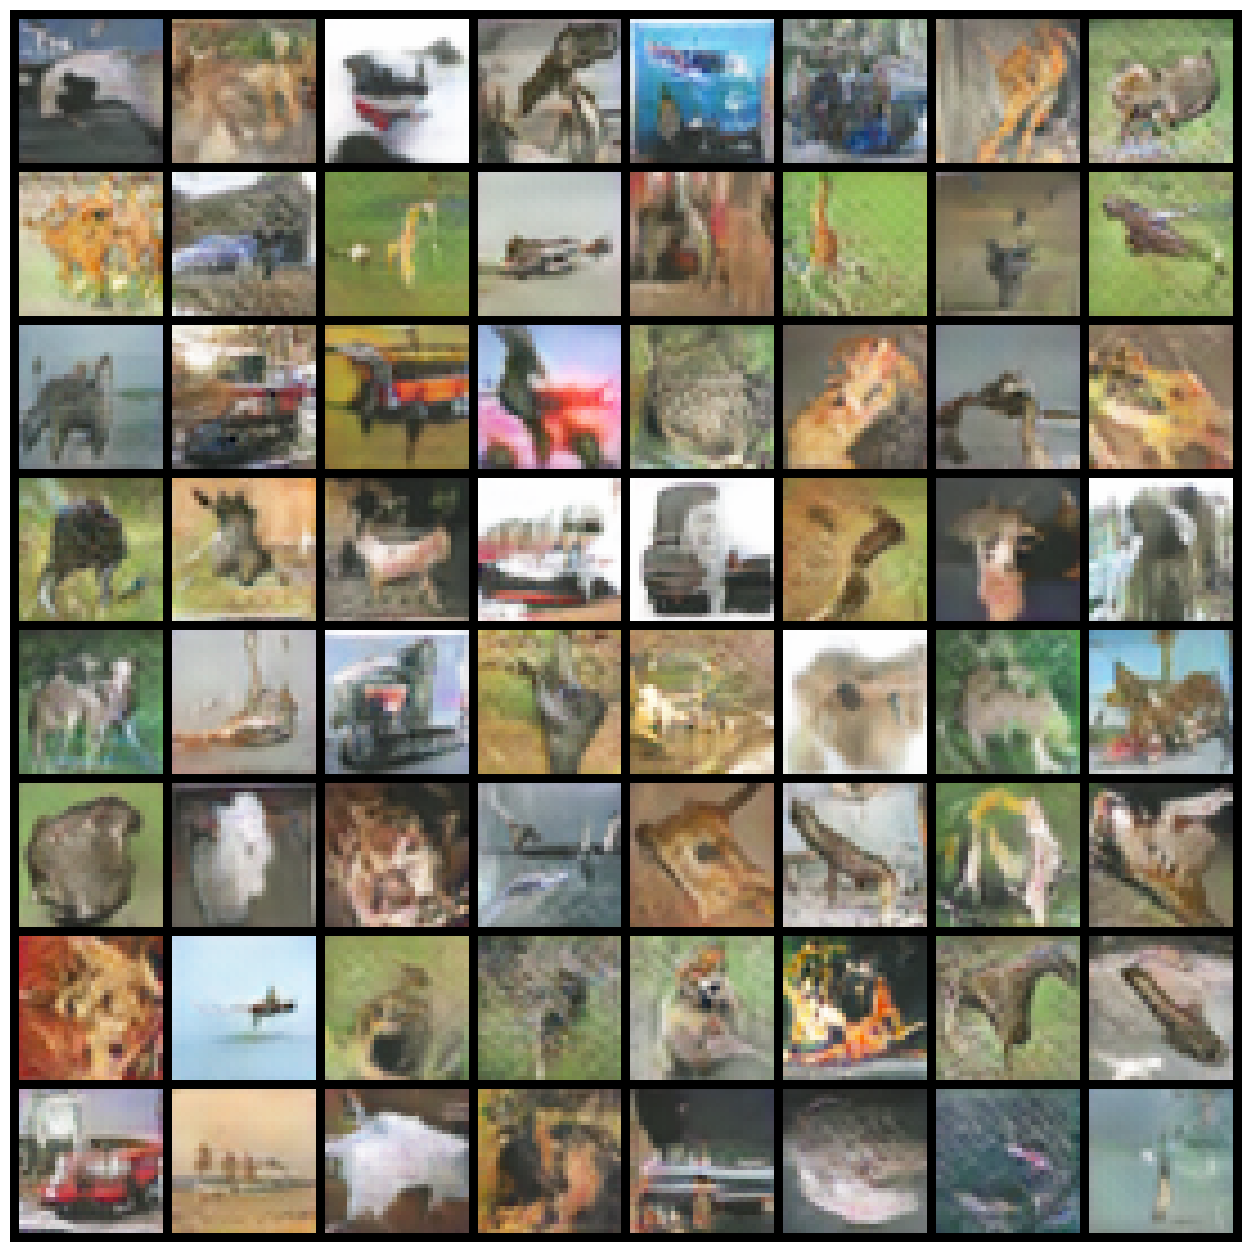

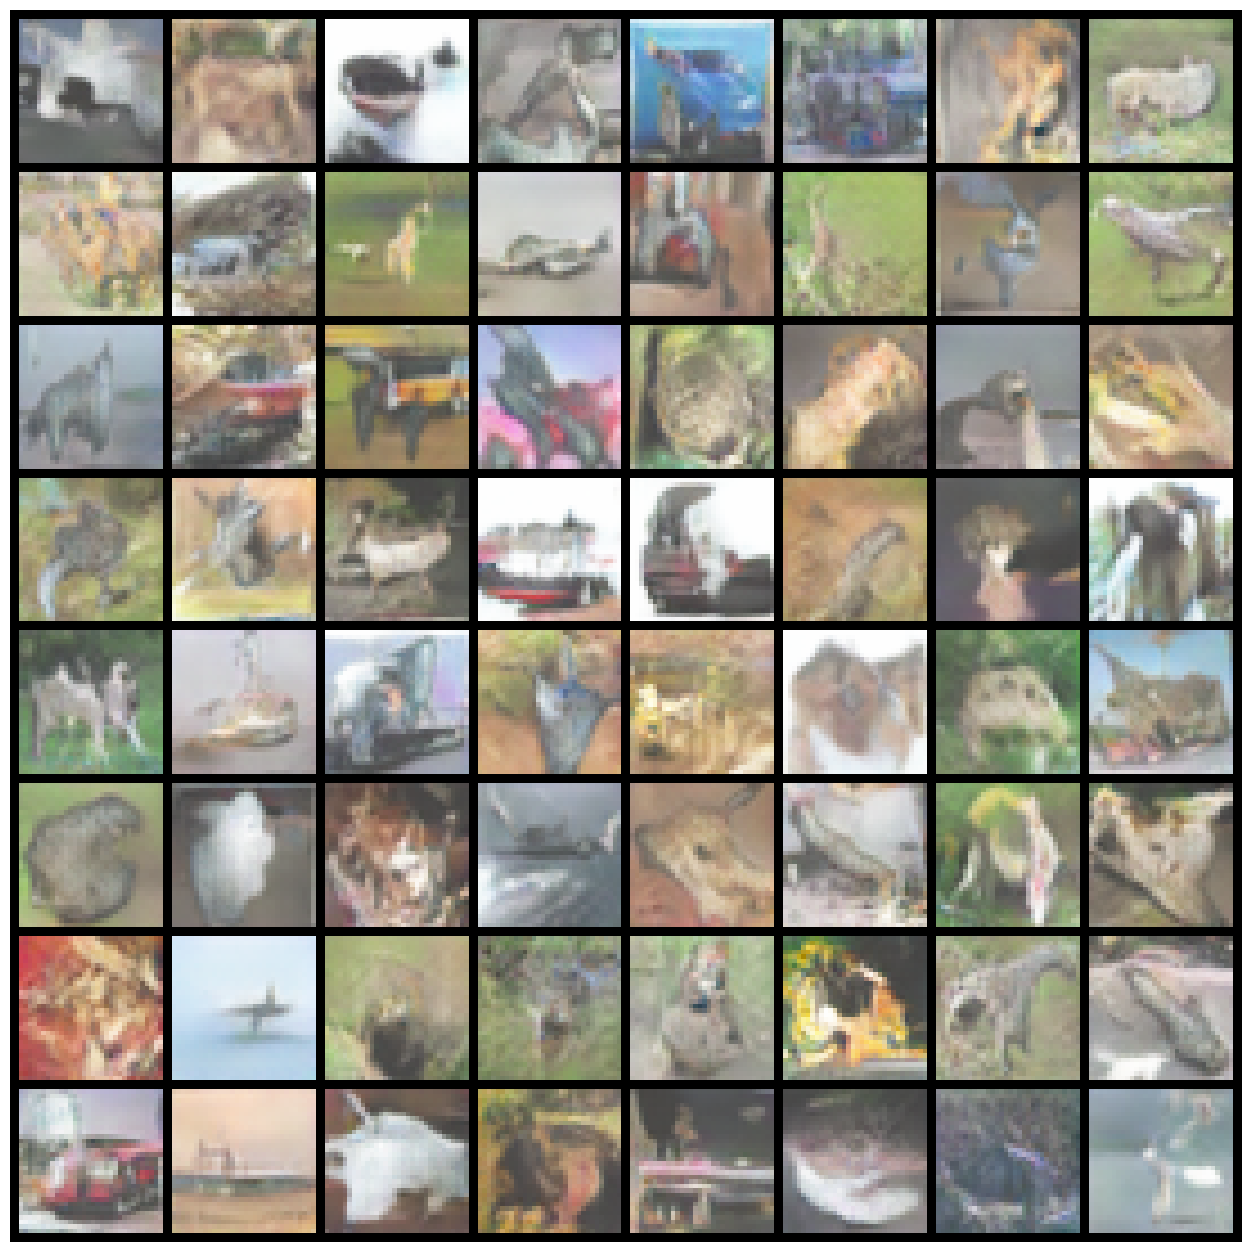

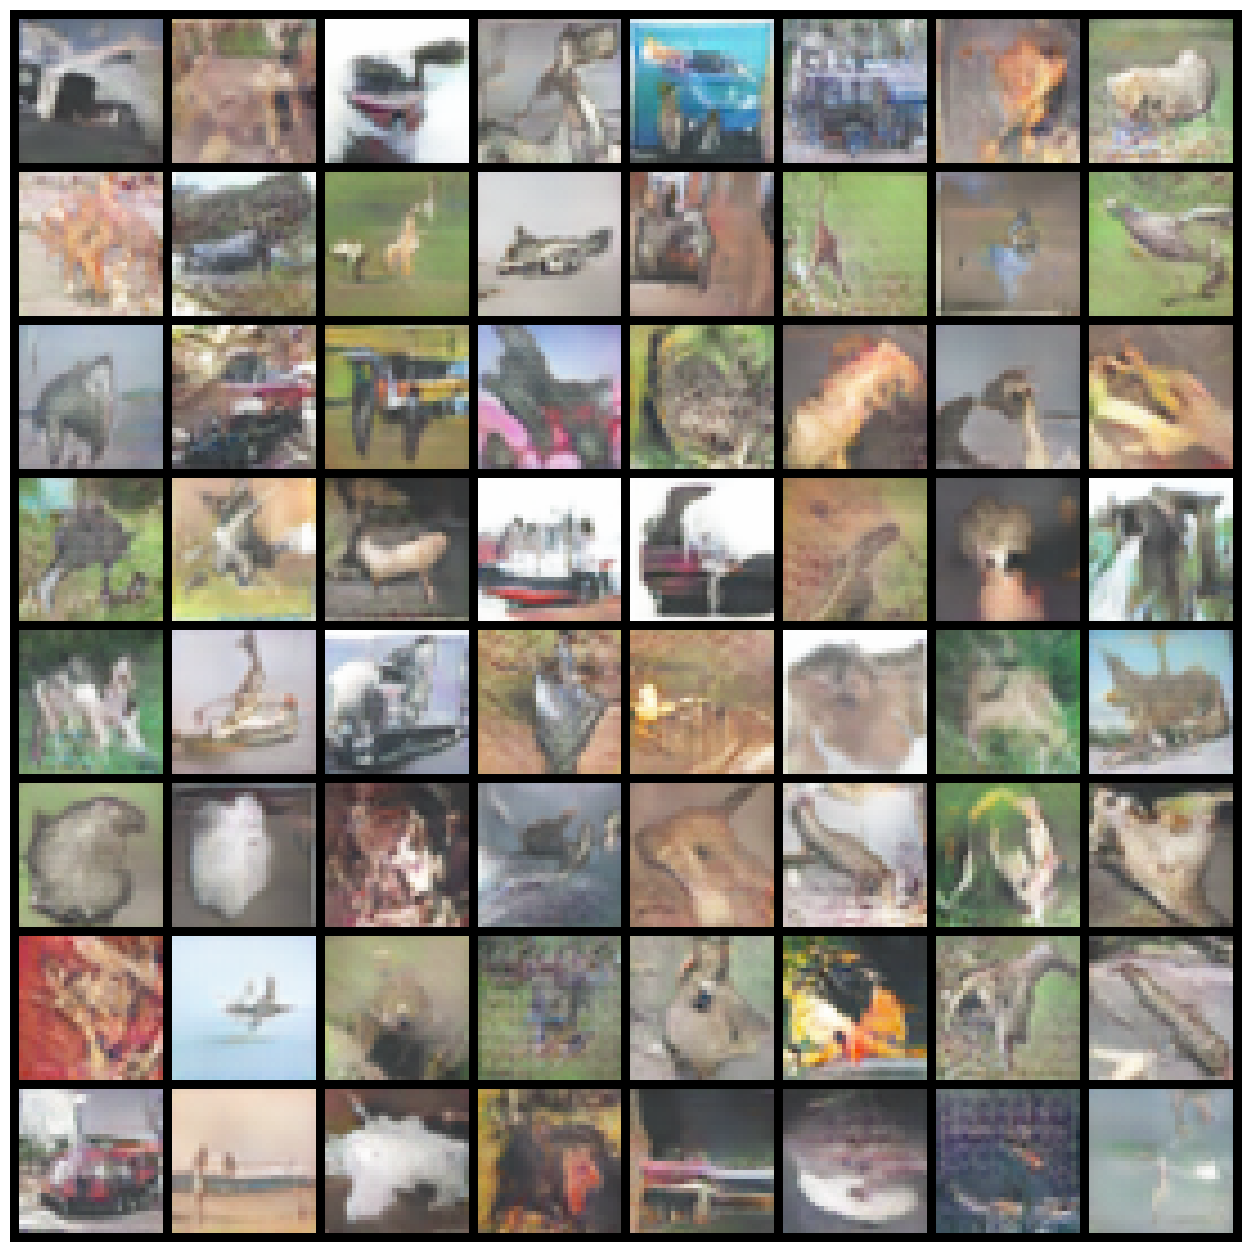

In [18]:
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

img_list = []
iters = 0

viz_noise = torch.Tensor(generate_latent_points(LATENT_DIM, N_BATCH//2)).to(device)

now = datetime.now()
timestamp = now.strftime("%Y%m%d-%H%M%S")
logdir = f"trainings/{timestamp}/"
writer = SummaryWriter(logdir)
global_step = 0

for epoch in range(NUM_EPOCHS):
    batch_iterator = tqdm(dataloader, desc=f"Processing Epoch {epoch+1:02d}")
    torch.cuda.empty_cache()
    for i, data in enumerate(batch_iterator):
        netD.train()
        netG.train()

        netD.zero_grad()
        x_real = data[0].to(device) # tuple (IMG, N°.)
        b_size = x_real.size(0)
        label = torch.full((b_size,), 1, dtype=torch.float, device=device)
        output = netD(x_real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        fake, _ = generate_fake_samples(netG, LATENT_DIM, N_BATCH//2)
        output = netD(torch.Tensor(fake).to(device).detach()).view(-1)
        label.fill_(0)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(1)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        writer.add_scalars('losses', {'DLoss': errD.item(), 'GLoss': errG.item()}, global_step)
        writer.flush()
        global_step += 1
        if (iters % 500 == 0) or ((epoch == NUM_EPOCHS-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(viz_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
        iters += 1
    if epoch % 5 == 0:
        save_image(img_list, epoch)

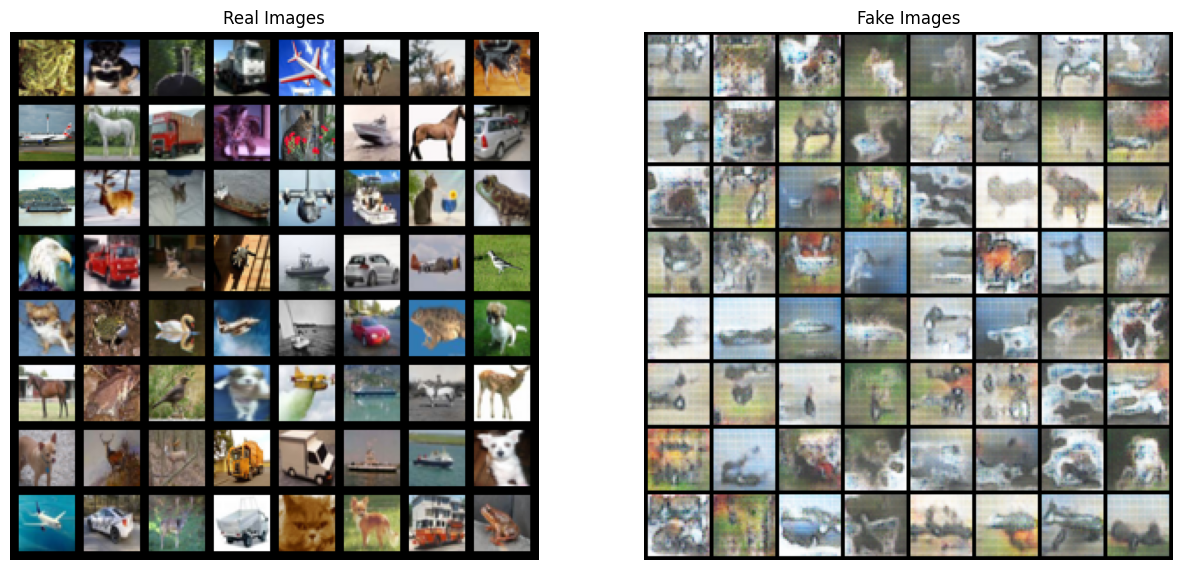

In [ ]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()